# **Data Science Process: Sentiment Analysis on IMDB Reviews**

In this project, we performed sentiment analysis on IMDB movie reviews using deep learning techniques. Below is a structured explanation of the entire data science workflow applied in this study.

**Dataset Downloading**

In [ ]:
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz

--2025-02-09 08:11:51--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz.1’

aclImdb_v1.tar.gz.1 100%[===================>]  80.23M  7.45MB/s    in 11s     

2025-02-09 08:12:02 (7.36 MB/s) - ‘aclImdb_v1.tar.gz.1’ saved [84125825/84125825]



In [ ]:
import os
import pandas as pd

def load_imdb_data(directory):
    data = []
    labels = []

    for label in ["pos", "neg"]:
        folder_path = os.path.join(directory, label)
        for file in os.listdir(folder_path):
            with open(os.path.join(folder_path, file), encoding="utf-8") as f:
                data.append(f.read())
                labels.append("positive" if label == "pos" else "negative")  # Store as text

    return pd.DataFrame({"review": data, "sentiment": labels})

# Load training and test data
train_df = load_imdb_data("aclImdb/train")
test_df = load_imdb_data("aclImdb/test")

# Combine them into a single DataFrame
df = pd.concat([train_df, test_df], ignore_index=True)

# ✅ Ensure processed data is saved OUTSIDE aclImdb
output_dir = "/content"
os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist
output_path = os.path.join(output_dir, "IMDB Dataset.csv")
df.to_csv(output_path, index=False)

print(f"Processed dataset saved at: {output_path}")
df.head()

Processed dataset saved at: /content/IMDB Dataset.csv


,review,sentiment
0,When its DVD was released i came to market and...,positive
1,Michael Cacoyannis has had a relatively long c...,positive
2,I think this has the potential of being the be...,positive
3,One of the best movies for all ages. You will ...,positive
4,The idea ia a very short film with a lot of in...,positive


In [ ]:
# Install required libraries
!pip install wandb tensorflow pandas numpy scikit-learn nltk wordcloud plotly seaborn

In [ ]:
#Importing Necessary Libraries
import warnings
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter

# NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from wordcloud import WordCloud

# Deep Learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split

# Weights & Biases imports
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

In [ ]:
# Suppress warnings
warnings.filterwarnings("ignore")

# Download NLTK Data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Initialize Weights & Biases project
wandb.init(project="imdb-sentiment-analysis")

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sasidharan1552004 (bsasidharan15) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


## **1. Data Collection & Preprocessing**
**Objective:** Convert raw IMDB reviews into a structured dataset suitable for machine learning.

- **Dataset Source:** IMDB dataset was downloaded and extracted.
- **Data Structure:** The dataset contains **50,000 movie reviews** labeled as either **positive** or **negative** sentiments.
- **Cleaning Steps:**
  - Removed HTML tags, special characters, and unnecessary symbols.
  - Converted all text to lowercase.
  - Removed stopwords (common words like "the", "is", "and") to improve text quality.
  - Tokenized words using **NLTK** and performed **stemming** (reducing words to their root form).
  - Removed duplicate entries.

In [ ]:
# Load the dataset
df = pd.read_csv('IMDB Dataset.csv')
print("First few rows:")
display(df.head())

print("\nLast few rows:")
display(df.tail())

print("\nDataset shape:", df.shape)
print("\nDataset info:")
df.info()

type(df)

First few rows:


,review,sentiment
0,When its DVD was released i came to market and...,positive
1,Michael Cacoyannis has had a relatively long c...,positive
2,I think this has the potential of being the be...,positive
3,One of the best movies for all ages. You will ...,positive
4,The idea ia a very short film with a lot of in...,positive



Last few rows:


,review,sentiment
49995,"This was a dreadful, boring movie, even for a ...",negative
49996,"Conclusion: very, but very, very boring, yet I...",negative
49997,Leslie Nielsen is usually someone whose movies...,negative
49998,An obscure horror show filmed in the Everglade...,negative
49999,These writers are trying to re-create the char...,negative



Dataset shape: (50000, 2)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


pandas.core.frame.DataFrame

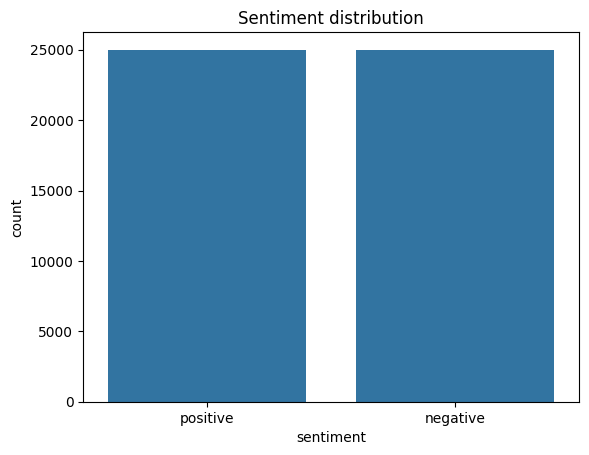

In [ ]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment distribution")
plt.show()

In [ ]:
for i in range(5):
    print("Review: ", [i])
    print(df['review'].iloc[i], "\n")
    print("Sentiment: ", df['sentiment'].iloc[i], "\n\n")

Review:  [0]
When its DVD was released i came to market and bought it. And i think my money was on right way as i expected before buying it. Awesome movie what else i can say for Will Smith, He's been an awesome actor like always whether in actions movies or serious. Always he gives a record braking performance. I think this is the movie after August Rush which makes a person cry while watching it. The way the director described the story was really awesome. His previous life and his new life in movie was correctly elaborated to the audience. Even i could not find any fault in the story or the way they shoot it. I think its DVD should be a household because this will be really a nice thing for your collection. It is not the movie which needs pop-corns for enjoyment, this is the movie which let the audience learn a lesson. now what is the lesson you can see that while watching. And i advise those people who are movie critics please watch this if you could find any criticism about this m

In [ ]:
def no_of_words(text):
    words = text.split()
    return len(words)

df['word count'] = df['review'].apply(no_of_words)
print(df.head())

                                              review sentiment  word count
0  When its DVD was released i came to market and...  positive         192
1  Michael Cacoyannis has had a relatively long c...  positive         167
2  I think this has the potential of being the be...  positive         109
3  One of the best movies for all ages. You will ...  positive          85
4  The idea ia a very short film with a lot of in...  positive         144


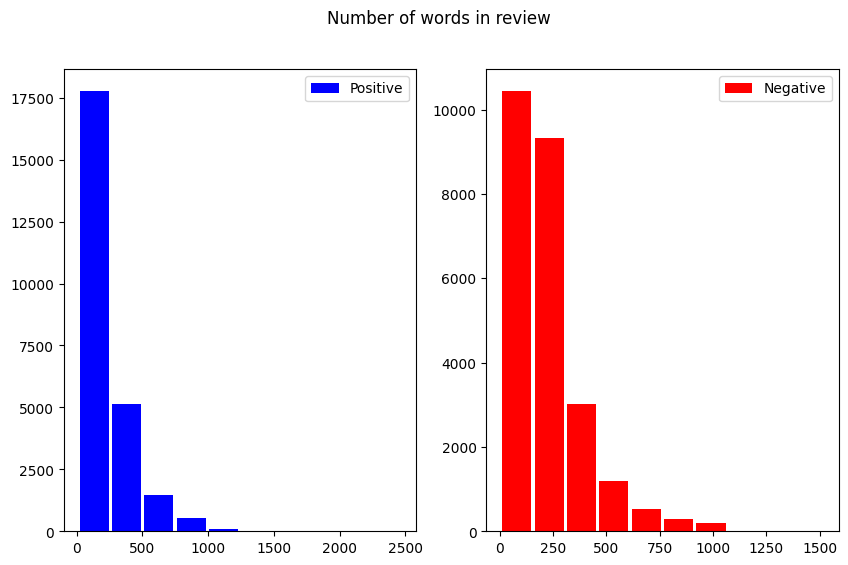

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['word count'], label='Positive', color='blue', rwidth=0.9)
ax[0].legend(loc='upper right')
ax[1].hist(df[df['sentiment'] == 'negative']['word count'], label='Negative', color='red', rwidth=0.9)
ax[1].legend(loc='upper right')
fig.suptitle("Number of words in review")
plt.show()

In [ ]:
df.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)
print(df.head())

                                              review  sentiment  word count
0  When its DVD was released i came to market and...          1         192
1  Michael Cacoyannis has had a relatively long c...          1         167
2  I think this has the potential of being the be...          1         109
3  One of the best movies for all ages. You will ...          1          85
4  The idea ia a very short film with a lot of in...          1         144


In [ ]:
try:
    stop_words = set(stopwords.words('english'))
    use_nltk = True
except Exception as e:
    print(f"NLTK download failed: {e}")
    print("Falling back to basic tokenization")
    use_nltk = False
    stop_words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once'])

def data_processing(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub('<br />', ' ', text)
    text = re.sub(r"https\S+|www\S+|http\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text_tokens = word_tokenize(text) if use_nltk else text.split()
    filtered_text = [w for w in text_tokens if w not in stop_words]
    return " ".join(filtered_text)

try:
    df['review'] = df['review'].apply(data_processing)
    print("Number of duplicate entries:", df.duplicated().sum())
    df = df.drop_duplicates('review')
except Exception as e:
    print(f"Error processing data: {e}")

Number of duplicate entries: 421


In [ ]:
stemmer = PorterStemmer()
def stemming(data):
    return ' '.join([stemmer.stem(word) for word in data.split()])
df['review'] = df['review'].apply(stemming)

df['word count'] = df['review'].apply(no_of_words)
print(df.head())

                                              review  sentiment  word count
0  dvd releas came market bought think money righ...          1          90
1  michael cacoyanni rel long career surprisingli...          1          92
2  think potenti best star trek seri yet say pote...          1          55
3  one best movi age never abl look lion king wit...          1          40
4  idea ia short film lot inform interest enterta...          1          68


## **2. Exploratory Data Analysis (EDA)**
**Objective:** Understand the dataset through statistical and visual analysis.

- **Sentiment Distribution:** A bar plot showed that the dataset was **balanced** (equal number of positive and negative reviews).
- **Word Count Analysis:** Positive and negative reviews were analyzed based on word length distribution.
- **Word Cloud Generation:** The most common words in **positive** and **negative** reviews were visualized.
- **Frequent Word Analysis:** Identified the most common words used in each sentiment category.

In [ ]:
pos_reviews =  df[df.sentiment == 1]
pos_reviews.head()

,review,sentiment,word count
0,dvd releas came market bought think money righ...,1,90
1,michael cacoyanni rel long career surprisingli...,1,92
2,think potenti best star trek seri yet say pote...,1,55
3,one best movi age never abl look lion king wit...,1,40
4,idea ia short film lot inform interest enterta...,1,68


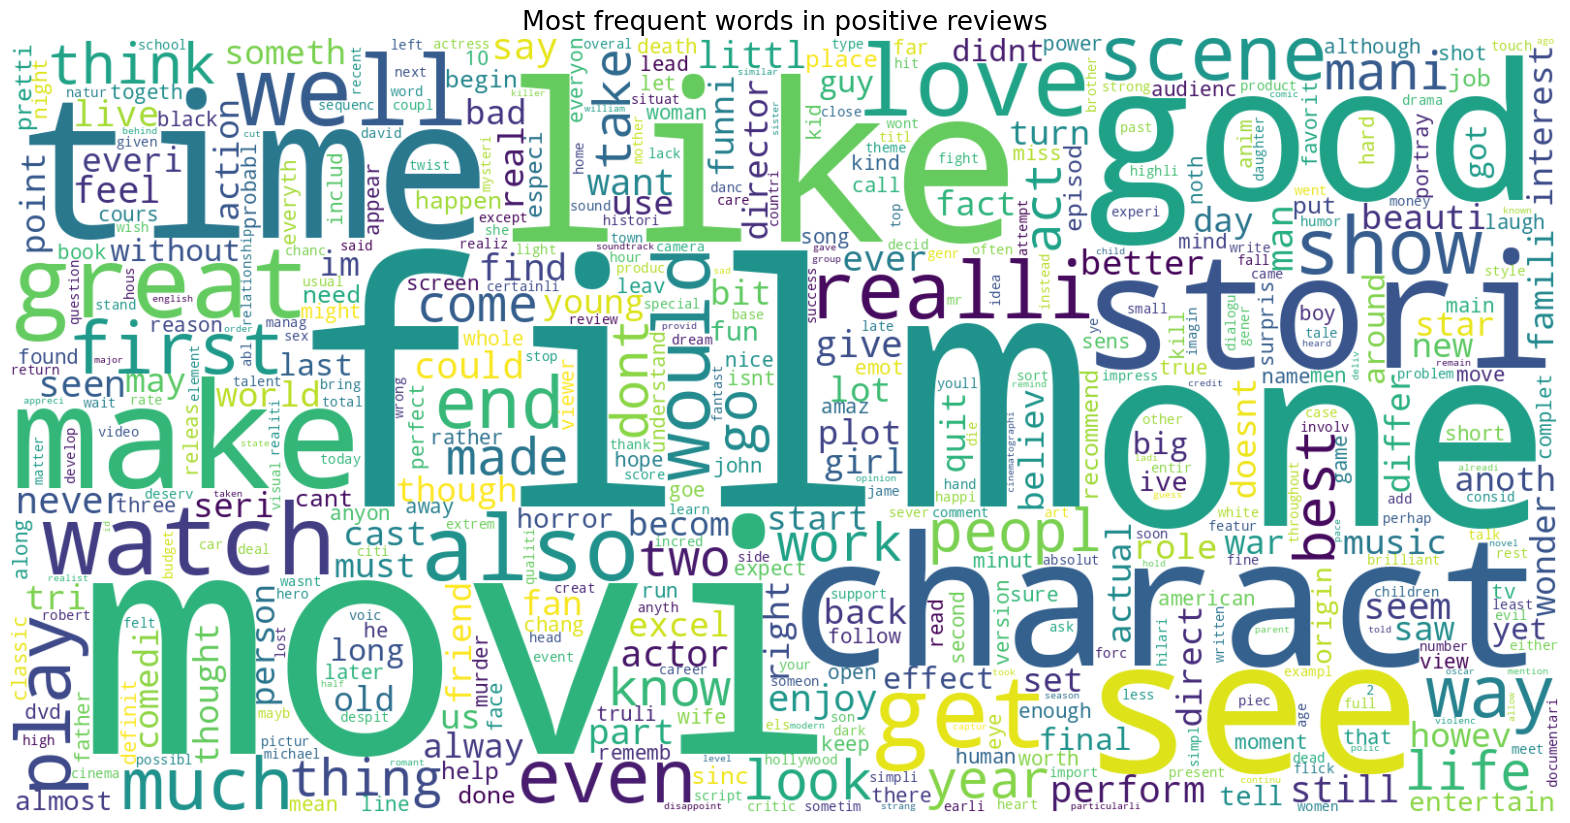

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Instead of joining all reviews, let's process a sample and use word frequencies
def create_fast_wordcloud(reviews_df, sample_size=10000):
    # Take a random sample of reviews if dataset is large
    if len(reviews_df) > sample_size:
        sample_reviews = reviews_df['review'].sample(n=sample_size, random_state=42)
    else:
        sample_reviews = reviews_df['review']

    # Count word frequencies
    words = ' '.join(sample_reviews).split()
    word_freq = Counter(words)

    # Generate WordCloud from frequencies
    wordcloud = WordCloud(
        max_words=500,
        width=1600,
        height=800,
        background_color='white'
    ).generate_from_frequencies(word_freq)

    # Create plot
    plt.figure(figsize=(20,15), facecolor='None')
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most frequent words in positive reviews', fontsize=19)
    plt.show()

# Use the optimized function
create_fast_wordcloud(pos_reviews)

In [ ]:
from collections import Counter
count = Counter()
for text in pos_reviews['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('film', 49740),
 ('movi', 43705),
 ('one', 27421),
 ('like', 19943),
 ('time', 15853),
 ('see', 14779),
 ('good', 14734),
 ('stori', 13872),
 ('charact', 13764),
 ('make', 13158),
 ('great', 12892),
 ('watch', 12676),
 ('get', 12569),
 ('love', 12142),
 ('well', 11701)]

In [ ]:
pos_words = pd.DataFrame(count.most_common(15))
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,film,49740
1,movi,43705
2,one,27421
3,like,19943
4,time,15853


In [ ]:
import plotly.express as px
px.bar(pos_words, x='count', y='word', title='Common words in positive reviews', color = 'word')

In [ ]:
neg_reviews =  df[df.sentiment == 0]
neg_reviews.head()

,review,sentiment,word count
12500,deriv predict rapereveng thriller thing your r...,0,133
12501,seen friend write feel familiar especi last 3 ...,0,136
12502,despit releas dvd blue underground five year a...,0,240
12503,well sorri mistak one line summaryrun peopl ru...,0,26
12504,worst de niro scorses collabor horribl agon vi...,0,79


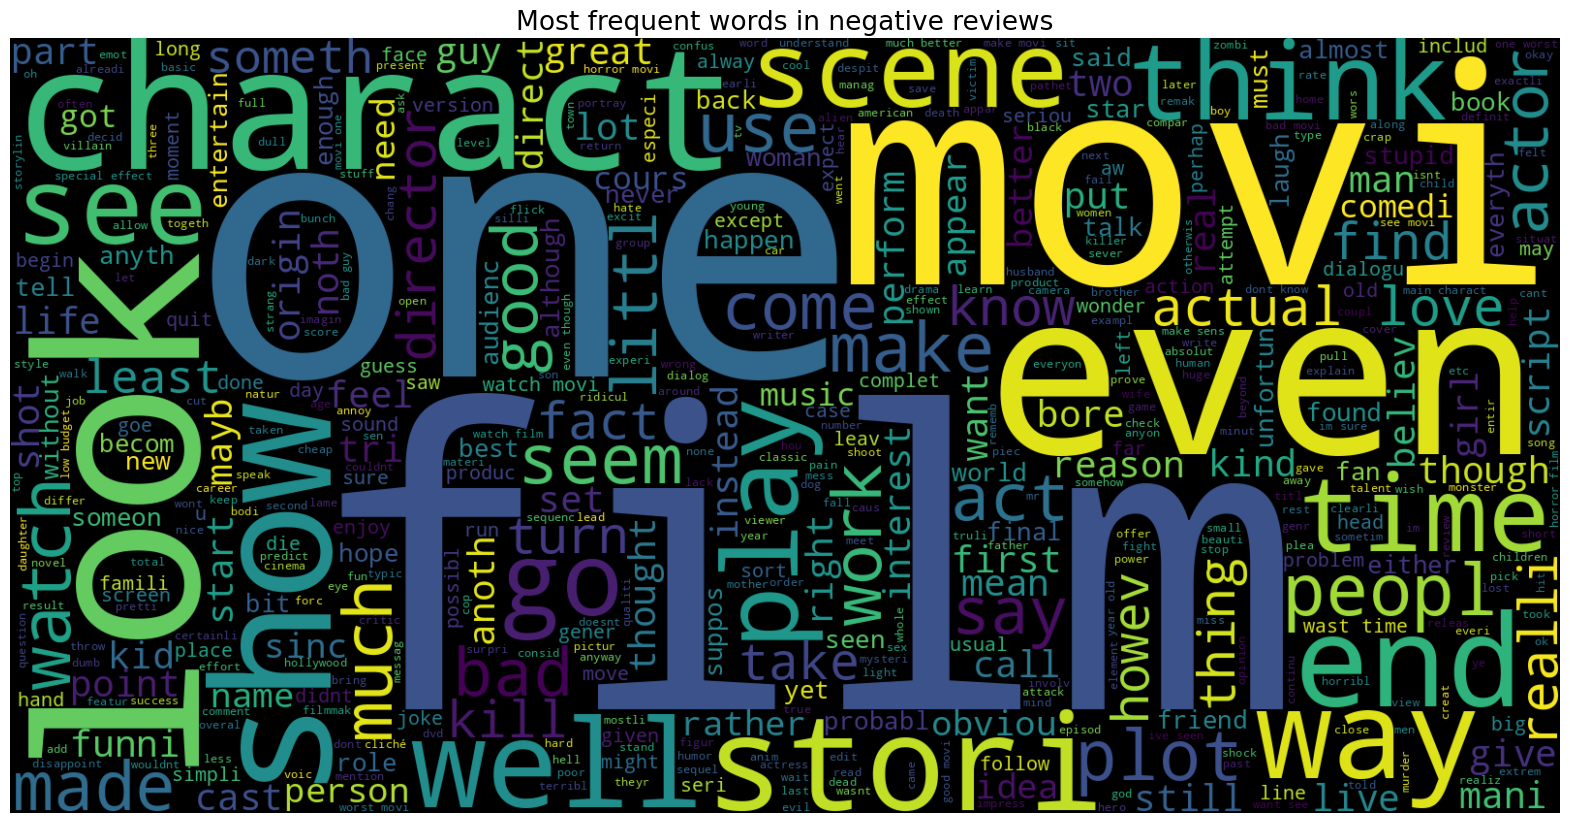

In [ ]:
text = ' '.join([word for word in neg_reviews['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in negative reviews', fontsize = 19)
plt.show()

In [ ]:
count = Counter()
for text in neg_reviews['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('movi', 56461),
 ('film', 43557),
 ('one', 25979),
 ('like', 23765),
 ('make', 15316),
 ('even', 15116),
 ('get', 15023),
 ('watch', 14648),
 ('time', 14574),
 ('good', 14395),
 ('bad', 14261),
 ('charact', 13985),
 ('would', 13502),
 ('see', 12818),
 ('realli', 12156)]

In [ ]:
neg_words = pd.DataFrame(count.most_common(15))
neg_words.columns = ['word', 'count']
neg_words.head()

,word,count
0,movi,56461
1,film,43557
2,one,25979
3,like,23765
4,make,15316


In [ ]:
px.bar(neg_words, x='count', y='word', title='Common words in negative reviews', color = 'word')

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
1,24881
0,24694


## **3. Data Preparation for Deep Learning**
**Objective:** Convert text into a numerical format for training machine learning models.

- **Tokenization:** Transformed text reviews into numerical sequences using a **Tokenizer**.
- **Padding Sequences:** Ensured all text sequences had the same length by padding shorter ones.
- **Train-Test Split:** Data was split into **training (80%)** and **testing (20%)** sets.

In [ ]:
train_data, test_data = train_test_split(df, test_size = 0.2, random_state=42)

In [ ]:
train_data.shape

(39660, 3)

In [ ]:
test_data.shape

(9915, 3)

In [ ]:
tokenizer = Tokenizer(num_words = 5000)
tokenizer.fit_on_texts(train_data["review"])

In [ ]:
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

In [ ]:
X_test,X_train

(array([[   0,    0,    0, ...,  321,  908,   60],
        [   0,    0,    0, ...,  326,   15,  509],
        [   0,    0,    0, ..., 3606,  500, 3510],
        ...,
        [   0,    0,    0, ...,   64,  453,   64],
        [ 885,  642, 1235, ..., 1156, 3341, 2985],
        [   0,    0,    0, ...,   37,  453,    2]], dtype=int32),
 array([[   0,    0,    0, ..., 1828,  266,  896],
        [   0,    0,    0, ..., 3579,    5, 2818],
        [   0,    0,    0, ...,  980, 2621,    1],
        ...,
        [   0,    0,    0, ..., 1402,  432,  603],
        [   0,    0,    0, ...,    1, 1014, 1705],
        [   0,    0,    0, ...,   20,  266,    5]], dtype=int32))

In [ ]:
Y_train = train_data["sentiment"]
Y_test = test_data["sentiment"]

In [ ]:
Y_train

,sentiment
3447,1
24462,0
27820,1
8168,1
16464,0
...,...
11306,1
45015,0
38351,0
860,1


## **4. Model Building & Training**
**Objective:** Train a deep learning model to classify reviews as positive or negative.

- **Model Architecture:**
  - **Embedding Layer:** Converts words into dense vector representations.
  - **LSTM Layer:** Captures sequential dependencies in text.
  - **Dropout Layer:** Prevents overfitting by randomly disabling neurons.
  - **Dense Layer:** Uses a **sigmoid activation function** to predict sentiment.

- **Hyperparameter Tuning:**
  - Trained models using **different learning rates (0.01, 0.005, 0.001)** to find the optimal configuration.
  - Used **Adam optimizer** for efficient learning.
  - Trained for **10 epochs** with **batch size = 64**.

---

## **5. Model Evaluation & Comparison**
**Objective:** Identify the best-performing model based on validation and test accuracy.

- **Metrics Used:**
  - **Training Loss & Accuracy:** Measures how well the model learns.
  - **Validation Loss & Accuracy:** Indicates generalization capability.
  - **Test Accuracy:** Measures real-world performance on unseen data.

- **Findings:**
  - **Learning Rate 0.001** achieved the highest **test accuracy (86.32%)**, making it the best model.
  - **Learning Rate 0.005** resulted in **overfitting** (good validation accuracy but high loss).
  - **Learning Rate 0.01** was too high, causing instability in learning.

In [ ]:
import wandb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import pickle

# Initialize Weights & Biases for first experiment
wandb.init(project="imdb-sentiment-analysis", name="Adam_lr0.01")

print("Training with Optimizer: Adam, Learning Rate: 0.01")

# Define model
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=200),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train model & log metrics
history = model.fit(
    X_train, Y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=1,
    callbacks=[WandbMetricsLogger(), WandbModelCheckpoint("best_model_lr0.01.keras")]
)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)

# Log training and validation metrics
for epoch in range(10):
    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": history.history["loss"][epoch],
        "Validation Loss": history.history["val_loss"][epoch],
        "Validation Accuracy": history.history["val_accuracy"][epoch],
        "Learning Rate": 0.01
    })

# Log final test accuracy
wandb.log({
    "Test Loss": test_loss,
    "Test Accuracy": test_acc,
    "Optimizer": "Adam",
    "Learning Rate": 0.01
})

# Save model and tokenizer
model.save('model_Adam_0.01.h5')
with open('tokenizer_Adam_0.01.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

wandb.finish()


Training with Optimizer: Adam, Learning Rate: 0.01
Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 331s 657ms/step - accuracy: 0.7691 - loss: 0.4748 - val_accuracy: 0.8707 - val_loss: 0.2907
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 378s 650ms/step - accuracy: 0.9043 - loss: 0.2340 - val_accuracy: 0.8787 - val_loss: 0.3041
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 385s 656ms/step - accuracy: 0.9226 - loss: 0.1979 - val_accuracy: 0.8743 - val_loss: 0.3044
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 379s 650ms/step - accuracy: 0.9374 - loss: 0.1604 - val_accuracy: 0.8762 - val_loss: 0.3269
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 386s 658ms/step - accuracy: 0.9476 - loss: 0.1385 - val_accuracy: 0.8699 - val_loss: 0.3654
Epoch 6/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 379s 652ms/step - accuracy: 0.9498 - loss: 0.1304 - val_accuracy: 0.8699 - val_loss: 0.3692
Epoch 7/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 382s 653ms/step - accuracy: 0.9545 - loss: 0.1220 - val_accuracy: 0.8694 - val_loss: 0.3970
Epoch 8/10
496/496 ━━━━━━

Epoch,▁▂▃▃▄▅▆▆▇█
Learning Rate,▁▁▁▁▁▁▁▁▁▁▁
Test Accuracy,▁
Test Loss,▁
Training Loss,█▄▃▂▂▁▁▁▁▁
Validation Accuracy,▃█▅▇▃▃▃▂▃▁
Validation Loss,▁▂▂▃▅▅▇▆██
epoch/accuracy,▁▅▆▇▇█████
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▁▁▁▁▁


In [ ]:
wandb.init(project="imdb-sentiment-analysis", name="Adam_lr0.005")

print("Training with Optimizer: Adam, Learning Rate: 0.005")

# Define model
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=200),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
optimizer = Adam(learning_rate=0.005)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train model & log metrics
history = model.fit(
    X_train, Y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=1,
    callbacks=[WandbMetricsLogger(), WandbModelCheckpoint("best_model_lr0.005.keras")]
)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)

# Log training and validation metrics
for epoch in range(10):
    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": history.history["loss"][epoch],
        "Validation Loss": history.history["val_loss"][epoch],
        "Validation Accuracy": history.history["val_accuracy"][epoch],
        "Learning Rate": 0.005
    })

# Log final test accuracy
wandb.log({
    "Test Loss": test_loss,
    "Test Accuracy": test_acc,
    "Optimizer": "Adam",
    "Learning Rate": 0.005
})

# Save model and tokenizer
model.save('model_Adam_0.005.h5')
with open('tokenizer_Adam_0.005.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

wandb.finish()


Training with Optimizer: Adam, Learning Rate: 0.005
Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 339s 666ms/step - accuracy: 0.7666 - loss: 0.4873 - val_accuracy: 0.8669 - val_loss: 0.3064
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 415s 732ms/step - accuracy: 0.8995 - loss: 0.2511 - val_accuracy: 0.8705 - val_loss: 0.3035
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 343s 690ms/step - accuracy: 0.9276 - loss: 0.1836 - val_accuracy: 0.8855 - val_loss: 0.3116
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 384s 694ms/step - accuracy: 0.9489 - loss: 0.1339 - val_accuracy: 0.8637 - val_loss: 0.3296
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 345s 696ms/step - accuracy: 0.9650 - loss: 0.1002 - val_accuracy: 0.8719 - val_loss: 0.4091
Epoch 6/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 376s 684ms/step - accuracy: 0.9695 - loss: 0.0849 - val_accuracy: 0.8700 - val_loss: 0.4267
Epoch 7/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 392s 706ms/step - accuracy: 0.9802 - loss: 0.0608 - val_accuracy: 0.8637 - val_loss: 0.5339
Epoch 8/10
496/496 ━━━━━

Epoch,▁▂▃▃▄▅▆▆▇█
Learning Rate,▁▁▁▁▁▁▁▁▁▁▁
Test Accuracy,▁
Test Loss,▁
Training Loss,█▅▄▃▂▂▁▁▁▁
Validation Accuracy,▃▄█▂▄▄▂▄▁▃
Validation Loss,▁▁▁▂▃▄▆▇▇█
epoch/accuracy,▁▄▆▆▇▇████
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▂▂▁▁▁▁


In [ ]:
wandb.init(project="imdb-sentiment-analysis", name="Adam_lr0.001")

print("Training with Optimizer: Adam, Learning Rate: 0.001")

# Define model
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=200),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train model & log metrics
history = model.fit(
    X_train, Y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=1,
    callbacks=[WandbMetricsLogger(), WandbModelCheckpoint("best_model_lr0.001.keras")]
)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)

# Log training and validation metrics
for epoch in range(10):
    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": history.history["loss"][epoch],
        "Validation Loss": history.history["val_loss"][epoch],
        "Validation Accuracy": history.history["val_accuracy"][epoch],
        "Learning Rate": 0.001
    })

# Log final test accuracy
wandb.log({
    "Test Loss": test_loss,
    "Test Accuracy": test_acc,
    "Optimizer": "Adam",
    "Learning Rate": 0.001
})

# Save model and tokenizer
model.save('model_Adam_0.001.h5')
with open('tokenizer_Adam_0.001.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

wandb.finish()


Training with Optimizer: Adam, Learning Rate: 0.001
Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 359s 711ms/step - accuracy: 0.7608 - loss: 0.4811 - val_accuracy: 0.8633 - val_loss: 0.3291
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 379s 705ms/step - accuracy: 0.8892 - loss: 0.2803 - val_accuracy: 0.8646 - val_loss: 0.3218
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 381s 703ms/step - accuracy: 0.9019 - loss: 0.2558 - val_accuracy: 0.8746 - val_loss: 0.3134
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 386s 710ms/step - accuracy: 0.9246 - loss: 0.2050 - val_accuracy: 0.8651 - val_loss: 0.3208
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 378s 703ms/step - accuracy: 0.9342 - loss: 0.1729 - val_accuracy: 0.8737 - val_loss: 0.3441
Epoch 6/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 383s 705ms/step - accuracy: 0.9452 - loss: 0.1491 - val_accuracy: 0.8729 - val_loss: 0.3870
Epoch 7/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 380s 702ms/step - accuracy: 0.9525 - loss: 0.1316 - val_accuracy: 0.8652 - val_loss: 0.3826
Epoch 8/10
496/496 ━━━━━

Epoch,▁▂▃▃▄▅▆▆▇█
Learning Rate,▁▁▁▁▁▁▁▁▁▁▁
Test Accuracy,▁
Test Loss,▁
Training Loss,█▅▅▄▃▃▂▂▂▁
Validation Accuracy,▂▂█▃▇▇▃▁▃▂
Validation Loss,▂▁▁▁▃▅▄▆▆█
epoch/accuracy,▁▄▅▆▆▇▇▇██
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▅▄▃▃▂▂▂▁


## Analysis & Insights

### 1. Effect of Hyperparameters on Training and Validation Loss/Accuracy
- **Training Loss**: The lowest training loss is observed at a learning rate of **0.005**, while it increases at **0.01**.
- **Validation Loss**: The highest validation loss occurs at **0.005**, suggesting overfitting, whereas the lowest is at **0.01**.
- **Validation Accuracy**: Peaks at **0.005**, indicating strong learning but potential overfitting.
- **Test Accuracy**: The best test accuracy is achieved at **0.001**.

### 2. Best Experiment & Why?
- **Best Generalization:** Learning Rate = **0.001** (Low validation loss and high test accuracy: **86.32%**).
- **Overfitting Risk:** Learning Rate = **0.005** (High validation accuracy but also high validation loss).
- **Fastest Training:** Learning Rate = **0.005** (Lowest training loss, but does not generalize the best).

### 3. Other Findings & Explanations
- **Higher learning rates (0.01)** show higher training loss but better validation loss, indicating aggressive learning.
- **Overfitting observed in LR=0.005**, as validation loss is significantly higher than training loss.
- **Test accuracy follows validation accuracy trends**, confirming validation performance as a good generalization indicator.

